In [3]:
import os
import cv2 
import dlib 
import keras
import imutils
import numpy as np 
import pandas as pd 
from imutils import face_utils
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import regularizers
from keras import backend as K
from keras.preprocessing import image
from keras.layers import MaxPooling2D  
from keras.layers import Convolution2D 
from keras.models import Model, Sequential
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.image import ImageDataGenerator
from keras.applications.mobilenet import preprocess_input
from tensorflow.keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop 
from keras.layers.normalization import layer_normalization
from keras.layers import Dense, GlobalAveragePooling2D, MaxPooling2D, Conv2D, Dropout, Flatten, MaxPool2D
from keras import regularizers
from keras.utils.vis_utils import plot_model
from keras.preprocessing import image
from keras.models import Model, Sequential
from keras.preprocessing.image import ImageDataGenerator
from keras.applications.mobilenet import preprocess_input
import glob
import shutil
import random
import warnings
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
warnings.simplefilter(action='ignore', category=FutureWarning)
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Activation
from keras.models import load_model
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import xgboost as xgb


In [3]:
classifier = Sequential()

# Convolution Layer 1
classifier.add(Conv2D(32, (3, 3), input_shape=(227, 227, 1), activation='relu', name='conv1'))

# Max Pooling Layer 1
classifier.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution Layer 2
classifier.add(Conv2D(64, (3, 3), activation='relu', name='conv2'))

# Max Pooling Layer 2
classifier.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution Layer 3
classifier.add(Conv2D(128, (3, 3), activation='relu', name='conv3'))

# Max Pooling Layer 3
classifier.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten Layer
classifier.add(Flatten())

# Fully Connected Layer 1
classifier.add(Dense(1024, activation='relu'))

# Batch Normalization Layer
classifier.add(BatchNormalization())
#group or layer

# Dropout Layer
classifier.add(Dropout(0.5))

# Output Layer
classifier.add(Dense(10, activation='softmax'))

# Summary of the model
classifier.summary()

# Compiling the model
adam = Adam(epsilon = 0.01)
classifier.compile(optimizer = adam, loss = 'categorical_crossentropy', metrics = ['accuracy'])

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1 (Conv2D)               (None, 225, 225, 32)      320       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 112, 112, 32)      0         
_________________________________________________________________
conv2 (Conv2D)               (None, 110, 110, 64)      18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 55, 55, 64)        0         
_________________________________________________________________
conv3 (Conv2D)               (None, 53, 53, 128)       73856     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 26, 26, 128)       0         
_________________________________________________________________
flatten (Flatten)            (None, 86528)             0

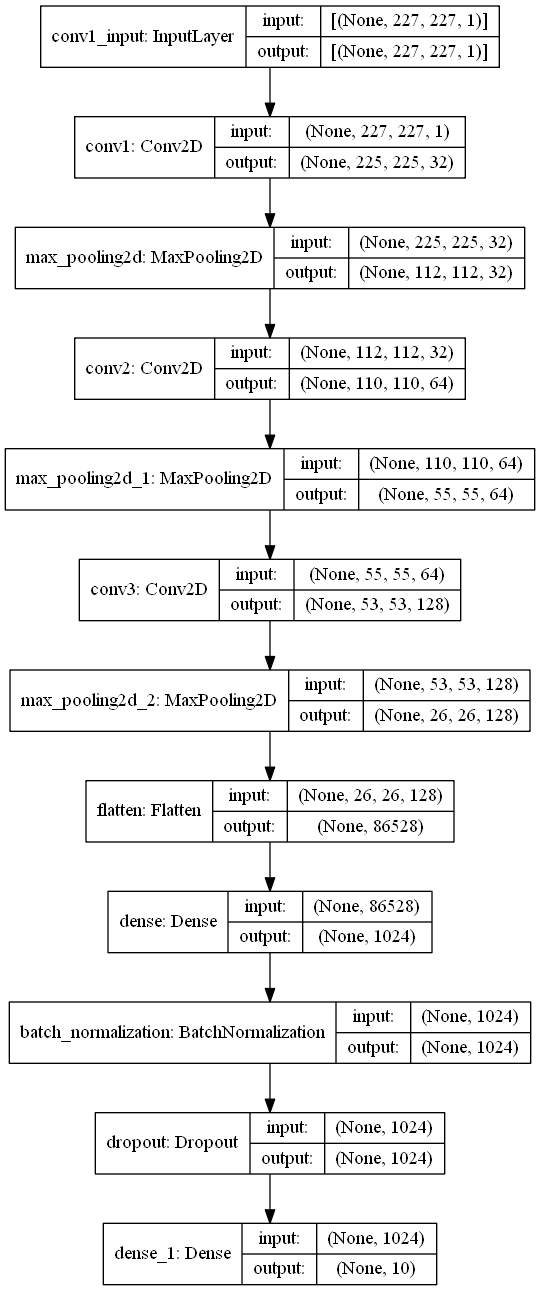

In [4]:
plot_model(classifier, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [6]:
def generator(dir, gen=image.ImageDataGenerator(rescale=1./511), shuffle=True,batch_size=1,target_size=(227,227),class_mode='categorical' ):

    return gen.flow_from_directory(dir,batch_size=batch_size,shuffle=shuffle,color_mode='grayscale',class_mode=class_mode,target_size=target_size)

BS= 32
TS=(227,227)
train_batch= generator('DATASET/Final/FINAL_2/train',shuffle=True, batch_size=BS,target_size=TS)
tr_SPE= len(train_batch.classes)//BS
print(tr_SPE)


tr_img,tr_labels= next(train_batch)

Found 1200 images belonging to 10 classes.
37


In [7]:
BS= 32
TS=(227,227)
test_batch= generator('DATASET/Final/FINAL_2/val',shuffle=True, batch_size=BS,target_size=TS)
te_SPE= len(test_batch.classes)//BS
print(te_SPE)


te_img,te_labels= next(test_batch)

Found 410 images belonging to 10 classes.
12


In [8]:
history = classifier.fit(x=train_batch,
    steps_per_epoch=tr_SPE,
    validation_data=test_batch,
    validation_steps=te_SPE,
    epochs=14,
    verbose=1
)

Epoch 1/14
37/37 [==============================] - 75s 2s/step - loss: 2.2499 - accuracy: 0.1772 - val_loss: 2.2903 - val_accuracy: 0.1797
Epoch 2/14
37/37 [==============================] - 55s 1s/step - loss: 1.8595 - accuracy: 0.3810 - val_loss: 2.2423 - val_accuracy: 0.2422
Epoch 3/14
37/37 [==============================] - 55s 1s/step - loss: 1.3257 - accuracy: 0.5736 - val_loss: 2.0926 - val_accuracy: 0.3047
Epoch 4/14
37/37 [==============================] - 54s 1s/step - loss: 0.9626 - accuracy: 0.7132 - val_loss: 1.9343 - val_accuracy: 0.3307
Epoch 5/14
37/37 [==============================] - 55s 1s/step - loss: 0.7565 - accuracy: 0.7663 - val_loss: 1.7236 - val_accuracy: 0.4115
Epoch 6/14
37/37 [==============================] - 66s 2s/step - loss: 0.6019 - accuracy: 0.8185 - val_loss: 1.7131 - val_accuracy: 0.3880
Epoch 7/14
37/37 [==============================] - 82s 2s/step - loss: 0.4668 - accuracy: 0.8810 - val_loss: 1.6745 - val_accuracy: 0.4115
Epoch 8/14
37/37 [==

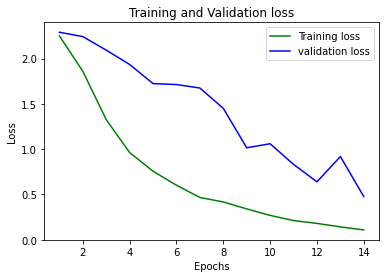

In [12]:
loss_train = history.history['loss']

loss_val = history.history['val_loss']

epochs = range(1,15)

plt.plot(epochs, loss_train, 'g', label='Training loss')

plt.plot(epochs, loss_val, 'b', label='validation loss')

plt.title('Training and Validation loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()

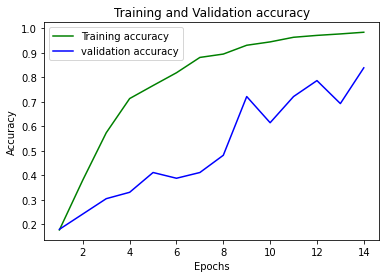

In [15]:
loss_train = history.history['accuracy']

loss_val = history.history['val_accuracy']

epochs = range(1,15)

plt.plot(epochs, loss_train, 'g', label='Training accuracy')

plt.plot(epochs, loss_val, 'b', label='validation accuracy')

plt.title('Training and Validation accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [ ]:
classifier.save('__Cnn_Xg_final_14.h5')

In [5]:
classifier = load_model('Cnn_Xg_final_14.h5')

In [8]:
classifier.evaluate(train_batch)

38/38 [==============================] - 30s 779ms/step - loss: 0.3643 - accuracy: 0.8675


[0.36425983905792236, 0.8675000071525574]

In [9]:
classifier.evaluate(test_batch)

13/13 [==============================] - 10s 800ms/step - loss: 0.4651 - accuracy: 0.8244


[0.4651142656803131, 0.8243902325630188]

In [10]:
y_train_pred=classifier.predict(train_batch)

In [11]:
y_test_pred=classifier.predict(test_batch)

In [12]:
train_features = classifier.predict(train_batch)
test_features = classifier.predict(test_batch)

In [13]:
tr_labels_shuffle = []
all_classes_before_shuffle = train_batch.classes
for i in range(1200):
    index_after_shuffle = train_batch.index_array[i]
    tr_labels_shuffle.append(all_classes_before_shuffle[index_after_shuffle])
tr_labels_shuffle = np.array(tr_labels_shuffle)

In [14]:
te_labels_shuffle = []
all_classes_before_shuffle = test_batch.classes
for i in range(410):
    index_after_shuffle = test_batch.index_array[i]
    te_labels_shuffle.append(all_classes_before_shuffle[index_after_shuffle])
te_labels_shuffle = np.array(te_labels_shuffle)

In [67]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import numpy as np

# Supposing one_hot_labels are your true labels and y_train_pred are the predictions

# Binarize the labels for roc_curve function
lb = LabelBinarizer()
lb.fit(te_labels_shuffle)
binarized_labels = lb.transform(te_labels_shuffle)

n_classes = binarized_labels.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(binarized_labels[:, i], y_test_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Optionally, you can compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(binarized_labels.ravel(), y_test_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


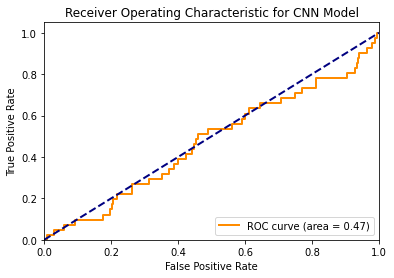

In [68]:
# Plot ROC curve for a specific class
plt.figure()
lw = 2
plt.plot(fpr[2], tpr[2], color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for CNN Model')
plt.legend(loc="lower right")
plt.show()


In [18]:
probs = classifier.predict(train_batch)
test_features = classifier.predict(test_batch)
# Convert the one-hot encoded matrix to an array of class labels
#y_train_labels = train_batch.classes.argmax(axis=1)

# Train the XGBoost model on the flattened probabilities
xgb_model = xgb.XGBClassifier()
xgb_model.fit(probs, tr_labels_shuffle)

C:\Users\Dell\anaconda3\envs\tf-environment\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[14:55:12] WARNING: C:\Windows\Temp\abs_557yfx631l\croots\recipe\xgboost-split_1659548953302\work\src\learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=12,
              num_parallel_tree=1, objective='multi:softprob', predictor='auto',
              random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=None,
              subsample=1, tree_method='exact', validate_parameters=1,
              verbosity=None)

In [19]:
from sklearn.metrics import accuracy_score
xgb_preds = xgb_model.predict(test_features)

# Calculate accuracy of the XGBoost model
accuracy = accuracy_score(te_labels_shuffle, xgb_preds)

print("Accuracy:", accuracy*100)

Accuracy: 94.39024390243902


In [69]:
# Binarize the labels for roc_curve function
lb = LabelBinarizer()
lb.fit(te_labels_shuffle)
te_binarized_labels = lb.transform(te_labels_shuffle)
lb = LabelBinarizer()
lb.fit(xgb_preds)
xgb_binarized_labels = lb.transform(xgb_preds)

n_classes = binarized_labels.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(te_binarized_labels[:, i], xgb_binarized_labels[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Optionally, you can compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(te_binarized_labels.ravel(), xgb_binarized_labels.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


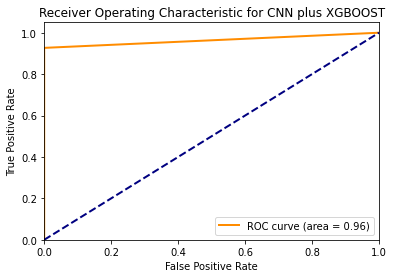

In [70]:
# Plot ROC curve for a specific class
plt.figure()
lw = 2
plt.plot(fpr[2], tpr[2], color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for CNN plus XGBOOST')
plt.legend(loc="lower right")
plt.show()


In [31]:
xgb_preds

array([7, 1, 5, 0, 2, 9, 0, 9, 0, 0, 0, 9, 8, 3, 5, 5, 0, 0, 1, 9, 0, 1,
       2, 6, 2, 4, 9, 3, 3, 7, 6, 6, 9, 7, 0, 7, 5, 4, 3, 4, 5, 0, 4, 1,
       8, 3, 7, 0, 2, 0, 8, 6, 4, 4, 3, 7, 0, 4, 3, 8, 4, 9, 2, 8, 0, 0,
       7, 0, 1, 8, 3, 5, 8, 9, 5, 2, 6, 6, 9, 0, 6, 3, 6, 3, 4, 9, 6, 7,
       5, 7, 4, 1, 6, 0, 2, 5, 0, 2, 1, 3, 1, 9, 7, 1, 7, 7, 4, 1, 7, 1,
       2, 0, 9, 9, 1, 5, 4, 6, 7, 0, 2, 7, 0, 0, 4, 1, 1, 1, 8, 5, 8, 7,
       9, 6, 5, 0, 5, 8, 1, 1, 6, 0, 5, 3, 3, 3, 8, 4, 9, 7, 4, 5, 9, 3,
       4, 5, 0, 3, 5, 4, 9, 0, 7, 3, 7, 8, 7, 8, 8, 8, 4, 3, 9, 0, 5, 0,
       8, 0, 9, 4, 2, 8, 2, 0, 3, 4, 5, 4, 5, 2, 0, 8, 7, 3, 1, 3, 1, 7,
       6, 2, 2, 7, 7, 8, 4, 2, 0, 9, 6, 4, 6, 1, 7, 2, 7, 8, 8, 9, 9, 8,
       6, 1, 9, 7, 4, 8, 0, 4, 7, 1, 6, 4, 0, 2, 4, 6, 4, 5, 5, 7, 1, 1,
       5, 4, 3, 7, 6, 3, 2, 1, 3, 2, 5, 1, 7, 8, 5, 6, 5, 0, 7, 5, 7, 2,
       8, 2, 3, 8, 3, 5, 7, 5, 0, 6, 2, 6, 9, 9, 7, 3, 2, 9, 5, 9, 8, 2,
       2, 1, 9, 1, 4, 7, 6, 3, 2, 4, 9, 6, 0, 6, 8,

In [32]:
te_labels_shuffle

array([7, 1, 5, 0, 2, 9, 0, 9, 0, 0, 0, 9, 8, 3, 5, 5, 0, 0, 1, 7, 0, 1,
       2, 6, 2, 4, 9, 3, 3, 7, 6, 6, 9, 7, 0, 7, 5, 4, 3, 4, 5, 0, 4, 1,
       8, 3, 7, 0, 2, 0, 8, 6, 4, 4, 3, 7, 0, 4, 3, 8, 4, 9, 2, 8, 0, 0,
       7, 0, 1, 8, 3, 5, 8, 9, 5, 2, 6, 8, 9, 4, 6, 3, 6, 3, 4, 9, 6, 7,
       5, 9, 4, 1, 6, 0, 2, 5, 0, 2, 1, 3, 1, 9, 7, 1, 7, 7, 4, 1, 7, 1,
       2, 0, 9, 9, 1, 5, 4, 6, 7, 0, 2, 7, 0, 0, 4, 1, 1, 1, 8, 5, 8, 7,
       9, 6, 5, 0, 5, 8, 1, 1, 6, 0, 5, 3, 3, 3, 8, 4, 9, 7, 4, 5, 9, 3,
       4, 5, 0, 3, 5, 4, 9, 0, 7, 3, 7, 8, 9, 8, 8, 8, 6, 3, 9, 4, 5, 0,
       8, 0, 9, 4, 2, 8, 2, 0, 3, 4, 5, 4, 5, 2, 0, 8, 7, 3, 1, 3, 1, 7,
       6, 2, 2, 7, 7, 8, 4, 2, 0, 9, 6, 4, 6, 1, 7, 2, 7, 8, 8, 9, 9, 8,
       6, 1, 9, 7, 4, 8, 0, 4, 7, 1, 6, 4, 0, 2, 4, 6, 4, 5, 5, 7, 1, 1,
       5, 4, 3, 9, 6, 5, 2, 1, 3, 2, 5, 1, 7, 5, 5, 6, 5, 0, 7, 5, 7, 2,
       8, 2, 3, 8, 3, 5, 7, 5, 0, 6, 2, 6, 9, 9, 7, 5, 2, 9, 5, 9, 8, 2,
       2, 1, 9, 1, 4, 7, 6, 3, 2, 4, 9, 6, 0, 6, 8,

In [ ]:
train_batch.labels

In [22]:
w0 = 0
w1 = 0
w2 = 0
w3 = 0
w4 = 0
w5 = 0
w6 = 0
w7 = 0
w8 = 0
w9 = 0

for i in xgb_preds:
    if i == 0 :
        w0 = w0+1
    elif i == 1 :
        w1 = w1 + 1
    elif i == 2 :
        w2 = w2 + 1
    elif i == 3 :
        w3 = w3 + 1
    elif i == 4 :
        w4 = w4 + 1
    elif i == 5 :
        w5 = w5 + 1
    elif i == 6 :
        w6 = w6 + 1
    elif i == 7 :
        w7 = w7 + 1
    elif i == 8 :
        w8 = w8 + 1
    elif i == 9 :
        w9 = w9+ 1
    


In [58]:
xgb_preds_list = [w0,w1,w2,w3,w4,w5,w6,w7,w8,w9]
x = ['Begin', 'Choose', 'Connection', 'Navigation', 'Next', 'Previous', 'Start', 'Stop', 'Hello', 'Web'] 

In [25]:
xgb_preds_list

[39, 42, 38, 39, 52, 40, 41, 36, 41, 42]

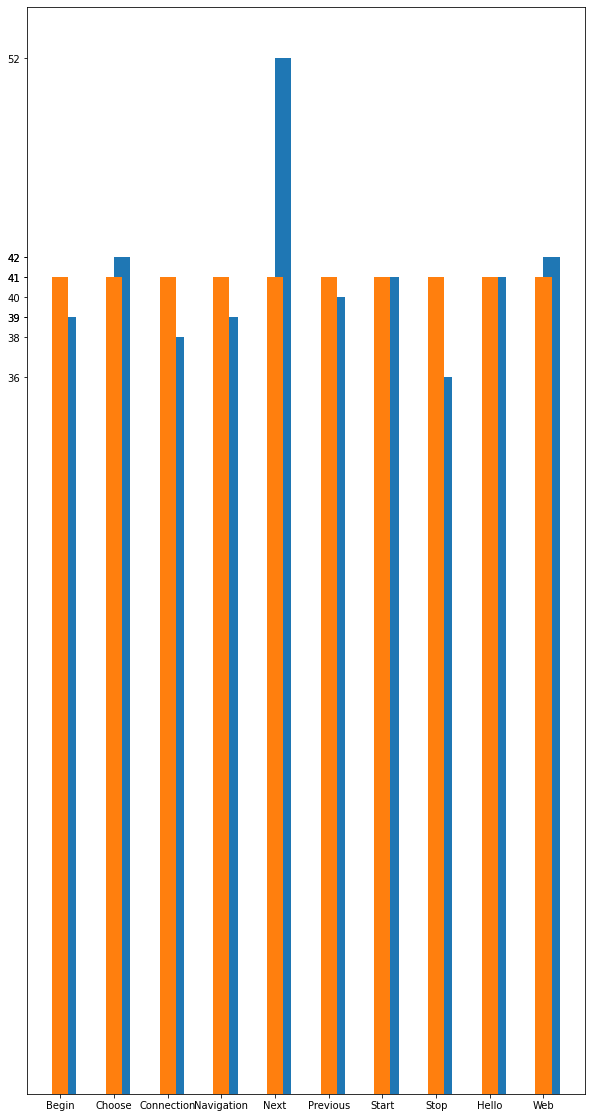

In [65]:
y_values = xgb_preds_list
text_values = x
x_values = np.arange(1, len(x) + 1, 1)

plt.figure(figsize=(10,20))
plt.bar(x_values, y_values, align='edge',width=0.3)
plt.bar(x_values, 41, align='center',width=0.3)
# Decide which ticks to replace.
plt.yticks(y_values)
plt.xticks(x_values, text_values)
plt.show()

In [ ]:
x